In [1]:
import os
from pathlib import Path
from typing import List, Tuple, Optional
import pandas as pd
import numpy as np


In [2]:

def read_recordings(
    base_dir: str,
    pattern: str = "test_*",
    sensor_cols: Optional[List[str]] = None,
    label_keywords: Tuple[str, str] = ("walk", "fall"),
    verbose: bool = True
) -> Tuple[List[np.ndarray], List[str], List[str], List[str]]:
    
    base = Path(base_dir)
    if sensor_cols is None:
        sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

    recordings = []
    labels = []
    file_names = []
    main_folders = []
    counter = 0

    folders = sorted(base.glob(pattern))
    total_files_est = 0

    for f in folders:
        if f.is_dir():
            total_files_est += len(list(f.glob("*.csv")))

    for folder in folders:
        if not folder.is_dir():
            continue
        for file in sorted(folder.glob("*.csv")):
            try:
                df = pd.read_csv(file)
                if df.empty:
                    if verbose:
                        print(f"⚠️ skipped empty file: {file}")
                    continue

                # مطمئن شو ستون‌های خواسته شده وجود دارن؛ در غیر این صورت تلاش کن تا نزدیک‌ترین ستونهارو برداری
                missing = [c for c in sensor_cols if c not in df.columns]
                if missing:
                    # اگر ستون‌ها نبودن، سعی می‌کنیم حداقل 6 ستون اول عددی را برداریم (ساده و مقاوم)
                    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                    if len(numeric_cols) >= len(sensor_cols):
                        chosen_cols = numeric_cols[:len(sensor_cols)]
                        if verbose:
                            print(f"ℹ️ file {file.name}: columns {sensor_cols} not all found, using {chosen_cols} instead.")
                    else:
                        # اگر ستون‌های عددی کم بود، رد کن
                        if verbose:
                            print(f"❌ file {file.name}: required columns {sensor_cols} missing and not enough numeric cols -> skipped")
                        continue
                else:
                    chosen_cols = sensor_cols

                # استخراج داده‌ها به صورت numpy (rows x features)
                arr = df[chosen_cols].to_numpy()
                if arr.size == 0:
                    if verbose:
                        print(f"⚠️ file {file.name} produced empty array -> skipped")
                    continue

                # نام فایل و لیبل‌گذاری ساده بر اساس اسم فایل
                fname = file.stem  # بدون .csv
                fname_lower = fname.lower()
                walk_kw, fall_kw = label_keywords[0].lower(), label_keywords[1].lower()
                if walk_kw in fname_lower:
                    label = "Walk"
                elif fall_kw in fname_lower:
                    label = "Fall"
                else:
                    label = "Unknown"

                recordings.append(arr)
                labels.append(label)
                file_names.append(fname)
                main_folders.append(folder.name)

                counter += 1
                if verbose:
                    print(f"\rProcessed: {counter}/{total_files_est} files", end="")

            except Exception as e:
                if verbose:
                    print(f"\n❌ Error reading {file}: {e}")

    if verbose:
        print(f"\n\n✅ Done. Total recordings: {len(recordings)}")
        counts = {l: labels.count(l) for l in set(labels)}
        print(f"Labels counts: {counts}")
    return recordings, labels, file_names, main_folders



In [3]:
# ===== Example usage =====
if __name__ == "__main__":
    base_dir = r"/Users/valerian/Documents/Coding/mdte-dt5/jupyter-notebook/data-collection/data"
    recs, labs, names, folders = read_recordings(base_dir, verbose=True)
    # recs, labs, names, folders = ut.read_recordings(base_dir, verbose=True)

    # نمونه: دسترسی به اولین رکوردینگ
    if recs:
        print("first recording shape:", recs[0].shape)
        print("first recording label:", labs[0])
        print("first recording file:", names[0], "from folder:", folders[0])


Processed: 200/200 files

✅ Done. Total recordings: 200
Labels counts: {'Fall': 100, 'Walk': 100}
first recording shape: (124, 6)
first recording label: Fall
first recording file: test_1_falling_10_124samples_5s from folder: test_1_20251024


In [4]:
import numpy as np
from typing import List, Tuple, Dict

def split_by_label(
    recordings: List[np.ndarray],
    labels: List[str],
    file_names: List[str] = None,
    main_folders: List[str] = None,
    walk_label: str = "walk",
    fall_label: str = "fall",
    use_folder_if_unknown: bool = True
) -> Dict[str, List]:
    """
    جداکردن رکوردها و لیبل‌ها به دو گروه Walk و Fall.

    ورودی:
      recordings: لیست ndarray هر رکوردینگ (n_rows x n_features)
      labels: لیست لیبل‌های متناظر (مثل 'Walk','Fall' یا 'Unknown')
      file_names: (اختیاری) لیست نام فایل‌ها برای خروجی
      main_folders: (اختیاری) لیست نام پوشه‌ها (برای fallback در صورت Unknown)
      walk_label / fall_label: رشته‌های مورد استفاده برای مقایسه (lowercased)
      use_folder_if_unknown: اگر لیبل 'Unknown' بود و main_folders موجود بود، از اسم پوشه برای تصمیم‌گیری استفاده می‌شود.

    خروجی: دیکشنری با کلیدهای:
      'walk_recordings', 'walk_labels', 'walk_files',
      'fall_recordings', 'fall_labels', 'fall_files'
    """
    walk_recs, walk_lbls, walk_files = [], [], []
    fall_recs, fall_lbls, fall_files = [], [], []

    wl = walk_label.lower()
    fl = fall_label.lower()

    for idx, rec in enumerate(recordings):
        lbl = labels[idx].lower() if labels and idx < len(labels) else "unknown"
        fname = file_names[idx] if file_names and idx < len(file_names) else None
        folder = main_folders[idx] if main_folders and idx < len(main_folders) else None

        assigned = False

        # اول بر اساس خودِ لیبل (case-insensitive)
        if wl in lbl:
            walk_recs.append(rec); walk_lbls.append(labels[idx]); walk_files.append(fname)
            assigned = True
        elif fl in lbl:
            fall_recs.append(rec); fall_lbls.append(labels[idx]); fall_files.append(fname)
            assigned = True

        # اگر هنوز نامشخص و بخوای از پوشه کمک بگیری
        if not assigned and use_folder_if_unknown and folder:
            folder_l = folder.lower()
            if wl in folder_l:
                walk_recs.append(rec); walk_lbls.append(labels[idx]); walk_files.append(fname)
                assigned = True
            elif fl in folder_l:
                fall_recs.append(rec); fall_lbls.append(labels[idx]); fall_files.append(fname)
                assigned = True

        # اگر هنوز نامشخص، می‌ذاریم توی Unknown => فعلاً به Walk یا Fall نمی‌فرستیم.
        if not assigned:
            # اگر خواستی می‌تونی اینجا رفتار دیگه‌ای تعریف کنی (مثلا همه Unknown رو به Walk ارسال کنی)
            pass

    return {
        "walk_recordings": walk_recs,
        "walk_labels": walk_lbls,
        "walk_files": walk_files,
        "fall_recordings": fall_recs,
        "fall_labels": fall_lbls,
        "fall_files": fall_files
    }

# ===== مثال استفاده =====
# فرض کن recs, labs, names, folders از تابع read_recordings برگشته
# result = split_by_label(recs, labs, file_names=names, main_folders=folders)
# سپس می‌تونی بهش دسترسی داشته باشی:
# walk_recs = result["walk_recordings"]
# fall_recs = result["fall_recordings"]
# print تعداد‌ها:
# print("Walk count:", len(walk_recs))
# print("Fall count:", len(fall_recs))


In [5]:
# ===== مثال استفاده =====
# فرض کن recs, labs, names, folders از تابع read_recordings برگشته
result = split_by_label(recs, labs, file_names=names, main_folders=folders)
# سپس می‌تونی بهش دسترسی داشته باشی:
walk_recs = result["walk_recordings"]
fall_recs = result["fall_recordings"]
# print تعداد‌ها:
print("Walk count:", len(walk_recs))
print("Fall count:", len(fall_recs))

Walk count: 100
Fall count: 100


In [6]:

walk_labels = result["walk_labels"]
fall_labels = result["fall_labels"]
class_names_combined = ["Walk", "Fall"]

walk_binary_labels = [0] * len(walk_recs)  # لیبل 1 برای Walk
fall_binary_labels = [1] * len(fall_recs)  # لیبل
numeric_labels_binary = [0, 1]

X_list = [walk_recs + fall_recs]  # لیست نهایی ویژگی‌ها
y_list = [walk_binary_labels + fall_binary_labels]  # لیست نهایی لیبل‌ها


In [7]:
import numpy as np
import math
from typing import List, Tuple, Optional
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def extract_features_signal(signal: np.ndarray, fs: int = 200) -> List[float]:
    """
    signal: می‌تواند شکل (n_samples, n_features) یا (3, n_samples) باشد.
            اگر بیشتر از 3 ستون داشته باشد، فرض می‌کند ستون‌های acc_x, acc_y, acc_z
            در سه ستون اول هستند. اگر کمتر داشت، مقدارهای خالی صفر فرض می‌شوند.
    خروجی: لیست ویژگی‌ها (float)
    """
    # تضمین numpy array و پاکسازی NaN/Inf
    sig = np.array(signal, dtype=float)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)

    # اگر شکل (n_samples, n_features) باشه -> تبدیل به (features, n_samples)
    if sig.ndim == 2 and sig.shape[0] > sig.shape[1]:
        # احتمالاً (n_samples, n_features)
        sig = sig.T

    # الآن sig باید (n_features, n_samples) باشه؛ اگر کمتر از 3 feature داریم، pad کن
    if sig.ndim == 1:
        sig = sig.reshape(1, -1)

    n_features = sig.shape[0]
    N = sig.shape[1] if sig.shape[1] > 0 else 1

    # استخراج محورها (فرض می‌کنیم acc_x, acc_y, acc_z در سه محور اول قرار دارن)
    if n_features >= 3:
        ax = sig[0, :]
        ay = sig[1, :]
        az = sig[2, :]
        # gx = sig[3, :] if n_features > 3 else np.zeros(N)
        # gy = sig[4, :] if n_features > 4 else np.zeros(N)
        # gz = sig[5, :] if n_features > 5 else np.zeros(N)
    else:
        # اگر کمتر از 3 محور باشه، تکمیل با صفر
        tmp = np.zeros((3, N))
        tmp[:n_features, :] = sig
        ax, ay, az = tmp[0, :], tmp[1, :], tmp[2, :]

    t = np.arange(N) / fs

    # magnitude
    mag = np.sqrt(ax**2 + ay**2 + az**2) + 1e-12  # small eps to avoid div0

    # Time-domain
    C1 = math.sqrt(np.mean(mag**2))  # RMS magnitude
    C2 = math.sqrt(np.mean(ax**2 + az**2))
    peak_to_peak = np.max(mag) - np.min(mag)
    C3 = math.sqrt(abs(peak_to_peak))
    # برای C4,C5 از تعریف‌های مشابه استفاده شده (محافظت در برابر div0)
    C4 = np.mean(np.arctan2(np.sqrt(ax**2 + az**2), -ay))
    C5 = np.std(np.arctan2(np.sqrt(ax**2 + az**2), np.where(np.abs(ay)>1e-12, ay, 1e-12)))
    C6 = (np.mean(ax[:-1]) * np.mean(ax[1:])) if N > 1 else 0.0
    jerk = np.diff(ax) / (np.diff(t) + 1e-12) if N > 1 else np.array([0.0])
    C7 = np.mean(np.abs(jerk)) if jerk.size > 0 else 0.0
    C8 = math.sqrt(np.std(ax)**2 + np.std(az)**2)
    C9 = math.sqrt(np.std(ax)**2 + np.std(ay)**2 + np.std(az)**2)
    C10 = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / N
    C11 = (np.sum(np.abs(ax)) + np.sum(np.abs(az))) / N
    C12 = np.sum(mag)
    C13 = np.sum(np.sqrt(ax**2 + az**2))
    vel_x = np.cumsum(ax) / fs
    vel_z = np.cumsum(az) / fs
    C14 = math.sqrt((np.sum(vel_x))**2 + (np.sum(vel_z))**2) / max(1, N)
    C15, C16, C17 = np.mean(ax), np.mean(ay), np.mean(az)
    C18, C19, C20 = np.std(ax), np.std(ay), np.std(az)

    # robust skew/kurtosis (catch warnings)
    try:
        C21, C22, C23 = skew(ax), skew(ay), skew(az)
    except Exception:
        C21, C22, C23 = 0.0, 0.0, 0.0
    try:
        C24, C25, C26 = kurtosis(ax), kurtosis(ay), kurtosis(az)
    except Exception:
        C24, C25, C26 = 0.0, 0.0, 0.0

    C27 = int(np.sum(np.diff(np.sign(mag - np.mean(mag))) != 0))

    # Frequency domain via Welch
    f, Pxx = welch(mag, fs=fs, nperseg=min(256, N)) if N >= 2 else (np.array([0.0]), np.array([0.0]))
    Pxx_sum = np.sum(Pxx)
    Pxx_norm = Pxx / Pxx_sum if Pxx_sum > 0 else Pxx
    try:
        C28 = entropy(Pxx_norm)
    except Exception:
        C28 = 0.0
    C29 = f[np.argmax(Pxx)] if (len(f) > 0 and np.any(Pxx)) else 0.0
    C30 = np.sum(Pxx[(f >= 0) & (f <= 5)]) if len(f) > 0 else 0.0

    # correlation features (guard for constant signals)
    def safe_corr(a, b):
        if np.std(a) < 1e-12 or np.std(b) < 1e-12:
            return 0.0
        return float(np.corrcoef(a, b)[0, 1])
    C31 = safe_corr(ax, ay)
    C32 = safe_corr(ay, az)
    C33 = safe_corr(ax, az)

    # feats = [
    #     C1, C2, C3, C4, C5, C6, C7, C8, C9, C10,
    #     C11, C12, C13, C14, C15, C16, C17, C18, C19, C20,
    #     C21, C22, C23, C24, C25, C26, C27, C28, C29, C30,
    #     C31, C32, C33

    feats = [
        
        C11, C12, C13,
        C31, C32, C33
    ]
    # تبدیل به float معمولی (برای سازگاری)
    return [float(x) for x in feats]


def features_from_recordings(recordings: List[np.ndarray], fs: int = 200, verbose: bool = False) -> np.ndarray:
    """
    تمام رکوردها را می‌گیرد و ماتریس ویژگی (n_records x n_features) برمی‌گرداند.
    """
    feat_list = []
    for i, rec in enumerate(recordings):
        try:
            feats = extract_features_signal(rec, fs=fs)
            feat_list.append(feats)
        except Exception as e:
            # اگر خطا شد، آرایه صفر بگذار
            if verbose:
                print(f"Error extracting features for record {i}: {e}")
            feat_list.append([0.0]*33)
    return np.array(feat_list, dtype=float)


# ==== مثال‌های کاربردی: تقسیم‌بندی و pipeline ====

# فرض کن walk_recs, fall_recs داری و walk_binary_labels و fall_binary_labels هم آماده‌ست
# ترکیب رکوردها و لیبل‌ها:
all_recs = walk_recs + fall_recs
all_labels = walk_binary_labels + fall_binary_labels  # 0 = Walk, 1 = Fall

# 1) روش پیشنهادی: اول تقسیم به train/test، بعد استخراج ویژگی
X_train_recs, X_test_recs, y_train, y_test = train_test_split(
    all_recs, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# استخراج ویژگی روی هر بخش جدا
X_train_feats = features_from_recordings(X_train_recs, fs=200)
X_test_feats = features_from_recordings(X_test_recs, fs=200)

# سپس استانداردسازی با آمار train (خیلی مهم)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)
X_test_scaled = scaler.transform(X_test_feats)

# حالا X_train_scaled, X_test_scaled و y_train,y_test آمادهٔ مدل‌سازی

# 2) روش دیگر (اول استخراج بعد تقسیم) — فقط برای وقتی که استخراج ویژگی کاملاً مستقل است
# (معمولاً روش 1 امن‌تره)
all_feats = features_from_recordings(all_recs, fs=200)
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    all_feats, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
# استانداردسازی:
scaler2 = StandardScaler()
X_a_train_scaled = scaler2.fit_transform(X_a_train)
X_a_test_scaled = scaler2.transform(X_a_test)

# ===== پایان مثال =====


In [8]:
# --- آماده‌سازی داده‌های ورودی (تصحیحِ X_list/y_list اشتباه) ---
# تبدیل لیست‌های walk/fall به یک X و y ساده
X_all = walk_recs + fall_recs            # لیست رکوردها (هر آیتم = ndarray زمان×ویژگی)
y_all = walk_binary_labels + fall_binary_labels  # لیست لیبل‌ها (0=Walk, 1=Fall)

print(f"Total records: {len(X_all)}  |  Walk: {len(walk_recs)}  Fall: {len(fall_recs)}")

# --- 1) تقسیم train/test (پیشنهادی: stratify برای حفظ نسبت کلاس‌ها) ---
test_size = 0.2
random_state = 42

X_train_recs, X_test_recs, y_train, y_test = train_test_split(
    X_all, y_all, test_size=test_size, random_state=random_state, stratify=y_all
)

print(f"Train records: {len(X_train_recs)}  |  Test records: {len(X_test_recs)}")

# --- 2) استخراج فیچر روی هر مجموعه جدا (به‌خاطر جلوگیری از data leakage) ---
X_train_feats = features_from_recordings(X_train_recs, fs=27, verbose=False)
X_test_feats = features_from_recordings(X_test_recs, fs=27, verbose=False)

print("Feature matrix shapes:", X_train_feats.shape, X_test_feats.shape)

# --- 3) استانداردسازی با آمارِ train و اعمال روی test ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)
X_test_scaled = scaler.transform(X_test_feats)

# ====== از اینجا بقیه کد آموزش/ارزیابی (copy/paste از بلوک بزرگ مدل‌ها) ======

# ====== imports مورد نیاز برای آموزش و ارزیابی مدل ها ======
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import joblib
import numpy as np
import pandas as pd
import time

# ====== تنظیمات پایه ======
seed = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# ====== تابع کمکی برای ارزیابی ======
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    res = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else None,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, zero_division=0)
    }
    print(f"\n--- Evaluation: {name} ---")
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(f"Precision: {res['precision']:.4f}")
    print(f"Recall: {res['recall']:.4f}")
    print(f"F1: {res['f1']:.4f}")
    if res['roc_auc'] is not None:
        print(f"ROC AUC: {res['roc_auc']:.4f}")
    print("Confusion matrix:")
    print(res['confusion_matrix'])
    print("\nClassification report:\n", res['classification_report'])
    return res

# ====== 1) Logistic Regression baseline ======
print("\nTraining Logistic Regression (baseline)...")
lr = LogisticRegression(class_weight='balanced', random_state=seed, max_iter=2000)
t0 = time.time()
lr.fit(X_train_scaled, y_train)
t1 = time.time()
print(f"Trained in {t1 - t0:.2f}s")
lr_res = evaluate_model(lr, X_test_scaled, y_test, name="LogisticRegression")

# ====== 2) Random Forest with RandomizedSearchCV ======
print("\nTraining Random Forest with RandomizedSearchCV...")
rf = RandomForestClassifier(random_state=seed, class_weight='balanced')
rf_param_dist = {
    "n_estimators": [100, 200, 400, 800],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}
rf_search = RandomizedSearchCV(
    rf, rf_param_dist, n_iter=20, cv=cv, scoring='f1',
    random_state=seed, n_jobs=-1, verbose=1
)
t0 = time.time()
rf_search.fit(X_train_scaled, y_train)
t1 = time.time()
print(f"RandomizedSearchCV finished in {t1 - t0:.1f}s")
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
rf_res = evaluate_model(best_rf, X_test_scaled, y_test, name="RandomForest (best)")

# نمایش 10 فیچر مهم (اگر تعداد فیچر کمتر از 10 تغییر کنه)
if hasattr(best_rf, "feature_importances_"):
    fi = best_rf.feature_importances_
    fi_idx = np.argsort(fi)[::-1]
    n_show = min(10, len(fi))
    print("\nTop feature importances (RandomForest):")
    for i in range(n_show):
        print(f"{i+1}. feature_{fi_idx[i]} -> {fi[fi_idx[i]]:.4f}")

# ====== 3) XGBoost with RandomizedSearchCV ======
print("\nTraining XGBoost with RandomizedSearchCV...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed, verbosity=0)
xgb_param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    xgb, xgb_param_dist, n_iter=20, cv=cv, scoring='f1',
    random_state=seed, n_jobs=-1, verbose=1
)
t0 = time.time()
xgb_search.fit(X_train_scaled, y_train)
t1 = time.time()
print(f"XGBoost RandomizedSearchCV finished in {t1 - t0:.1f}s")
best_xgb = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)
xgb_res = evaluate_model(best_xgb, X_test_scaled, y_test, name="XGBoost (best)")

# فیچر ایمپورتنس XGBoost
if hasattr(best_xgb, "feature_importances_"):
    fi = best_xgb.feature_importances_
    fi_idx = np.argsort(fi)[::-1]
    n_show = min(10, len(fi))
    print("\nTop feature importances (XGBoost):")
    for i in range(n_show):
        print(f"{i+1}. feature_{fi_idx[i]} -> {fi[fi_idx[i]]:.4f}")

# ====== 4) (اختیاری) cross-val score نهایی روی بهترین مدل ======
print("\nCross-val F1 on train for final RF model (5-fold):")
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores:", np.round(cv_scores, 4))
print("CV F1 mean ± std:", np.round(np.mean(cv_scores),4), "±", np.round(np.std(cv_scores),4))

# ====== 5) ذخیره بهترین مدل ها و scaler ======
joblib.dump(best_rf, "best_rf_model.joblib")
joblib.dump(best_xgb, "best_xgb_model.joblib")
joblib.dump(lr, "logistic_baseline.joblib")
joblib.dump(scaler, "scaler.joblib")
print("\nModels and scaler saved (joblib).")

# ====== 6) ساخت DataFrame نتایج برای مقایسه سریع ======
summary = pd.DataFrame({
    "model": ["LogisticRegression", "RandomForest", "XGBoost"],
    "accuracy": [lr_res["accuracy"], rf_res["accuracy"], xgb_res["accuracy"]],
    "precision": [lr_res["precision"], rf_res["precision"], xgb_res["precision"]],
    "recall": [lr_res["recall"], rf_res["recall"], xgb_res["recall"]],
    "f1": [lr_res["f1"], rf_res["f1"], xgb_res["f1"]],
    "roc_auc": [lr_res["roc_auc"], rf_res["roc_auc"], xgb_res["roc_auc"]],
})
print("\n=== Summary ===")
print(summary)
summary.to_csv("model_comparison_summary.csv", index=False)
print("Summary saved to model_comparison_summary.csv")


Total records: 200  |  Walk: 100  Fall: 100
Train records: 160  |  Test records: 40
Feature matrix shapes: (160, 6) (40, 6)

Training Logistic Regression (baseline)...
Trained in 0.01s

--- Evaluation: LogisticRegression ---
Accuracy: 0.9250
Precision: 0.8696
Recall: 1.0000
F1: 0.9302
ROC AUC: 0.9950
Confusion matrix:
[[17  3]
 [ 0 20]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.87      1.00      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


Training Random Forest with RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV finished in 6.5s
Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}

--- Evaluation: RandomForest (best) --

Computing learning curve for: Learning Curve - Random Forest  (scoring=f1)
Saved figure to: learning_curve_rf.png


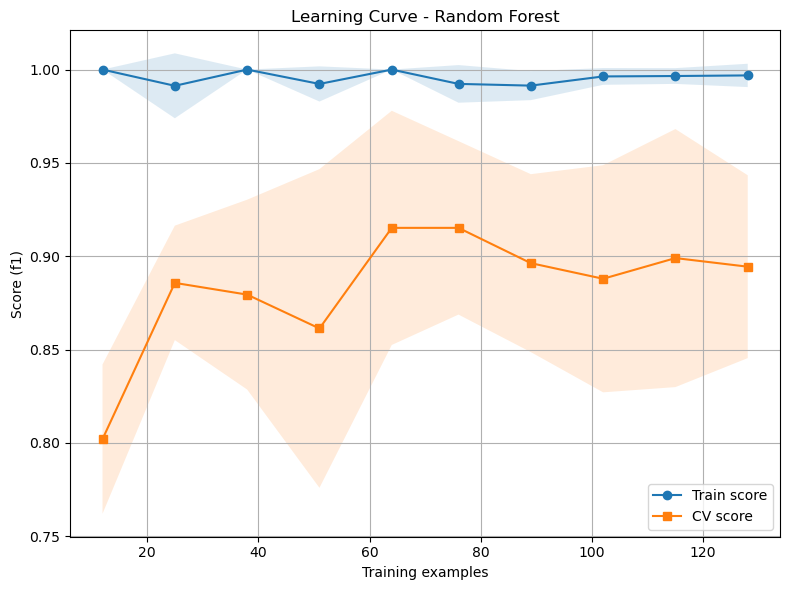

Computing learning curve for: Learning Curve - XGBoost  (scoring=f1)
Saved figure to: learning_curve_xgb.png


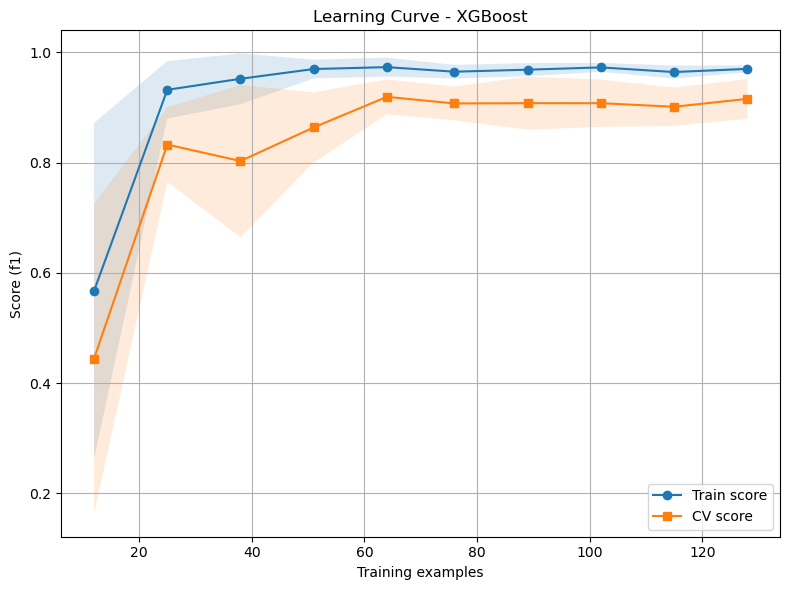

Computing learning curve for: Learning Curve - Logistic Regression  (scoring=f1)
Saved figure to: learning_curve_lr.png


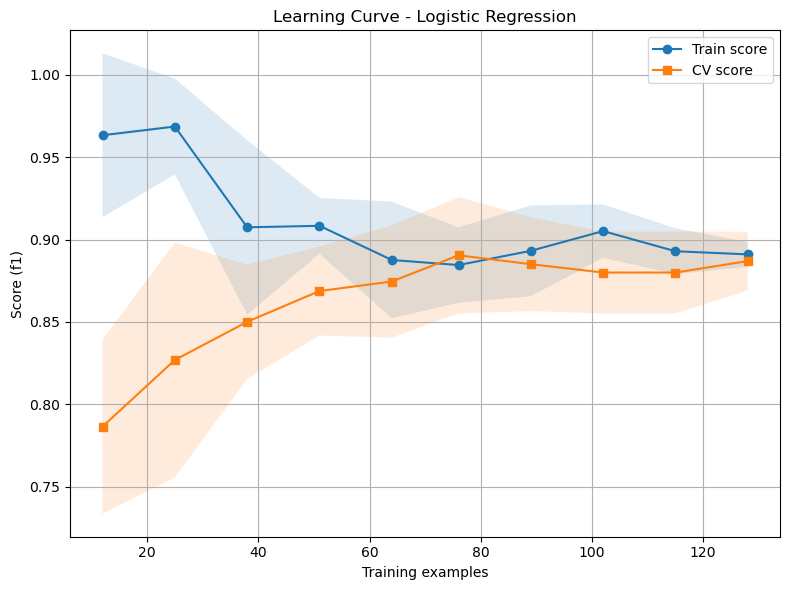

In [9]:
# Learning curve plots for models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y,
                        title="Learning Curve",
                        cv=None,
                        scoring='f1',
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        n_jobs=-1,
                        save_path=None):
    """
    رسم learning curve برای یک مدل:
      - model : estimator آماده (unfitted or fitted is fine; learning_curve will fit)
      - X, y : داده‌های train (توصیه: از X_train_scaled و y_train استفاده کن)
      - cv : cross-validation splitter (مثلاً StratifiedKFold)
      - scoring : معیار مورد نظر (پیش‌فرض 'f1')
      - train_sizes : نسبت یا تعداد نمونه‌هایی که برای رسم استفاده می‌کنیم
      - save_path : اگر مسیر فایل PNG داده شود، عکس را ذخیره می‌کند

    خروجی: محورهای (train_sizes, train_scores_mean, test_scores_mean) و نمایش نمودار
    """
    print(f"Computing learning curve for: {title}  (scoring={scoring})")
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X, y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        verbose=0,
        shuffle=True,
        random_state=42
    )

    # میانگین و انحراف معیار
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std  = np.std(train_scores, axis=1)
    test_scores_mean  = np.mean(test_scores, axis=1)
    test_scores_std   = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes_abs, train_scores_mean, marker='o', label='Train score')
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.15)
    plt.plot(train_sizes_abs, test_scores_mean, marker='s', label='CV score')
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.15)

    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(f"Score ({scoring})")
    plt.grid(True)
    plt.legend(loc="best")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Saved figure to: {save_path}")
    plt.show()

    # همچنین برمی‌گردونیم مقادیر عددی تا بتونی آنها را آنالیز کنی
    return {
        "train_sizes": train_sizes_abs,
        "train_scores_mean": train_scores_mean,
        "train_scores_std": train_scores_std,
        "test_scores_mean": test_scores_mean,
        "test_scores_std": test_scores_std
    }


# ======== چگونه اجرا کنی (مثال) ========
# فرض: best_rf, best_xgb, lr ساخته شده و X_train_scaled, y_train آماده‌اند.
# cv همان StratifiedKFold که قبلا ساختیم است.

# برای RandomForest
rf_lc = plot_learning_curve(best_rf, X_train_scaled, y_train,
                            title="Learning Curve - Random Forest",
                            cv=cv, scoring='f1',
                            train_sizes=np.linspace(0.1, 1.0, 10),
                            save_path="learning_curve_rf.png")

# برای XGBoost
xgb_lc = plot_learning_curve(best_xgb, X_train_scaled, y_train,
                             title="Learning Curve - XGBoost",
                             cv=cv, scoring='f1',
                             train_sizes=np.linspace(0.1, 1.0, 10),
                             save_path="learning_curve_xgb.png")

# برای Logistic Regression (baseline)
lr_lc = plot_learning_curve(lr, X_train_scaled, y_train,
                            title="Learning Curve - Logistic Regression",
                            cv=cv, scoring='f1',
                            train_sizes=np.linspace(0.1, 1.0, 10),
                            save_path="learning_curve_lr.png")


In [ ]:
import joblib

# Save the trained XGBoost model
joblib.dump(best_xgb, "best_xgb_model.joblib")

# Also save the scaler for preprocessing
joblib.dump(scaler, "scaler.joblib")

print("XGBoost model and scaler saved!")


XGBoost model and scaler saved!


Exception ignored in: <function ResourceTracker.__del__ at 0x104241bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106fd1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105e5dbc0>
Traceback (most recent call last